## Árboles de decisión
Son algoritmos de aprendizaje automático supervisado.
Son utilizados para desarrollar sistemas que predicen o clasifican observaciones futuras basándose en un conjunto de reglas de decisión.
Los árboles de decisión son muy utilizados porque representan reglas de la forma si - entonces, por lo que se pueden expresar fácilmente en una forma que todos podamos comprender.
En estas estructuras de árbol, las hojas representan etiquetas de clase y las ramas representan las conjunciones de características que conducen a esas etiquetas de clase.
Las instancias son clasificadas desde la raiz bajando por alguna de las ramas hasta llegar al nodo hoja que proporcionará la clasificación de la instancia.
Hay varios algoritmos disponibles, todos son básicamente similares: examinan todos los campos del conjunto de datos para detectar el que proporciona la mejor clasificación o predicción dividiendo los datos en subgrupos. El proceso se aplica de forma recursiva, dividiendo los subgrupos en unidades cada vez más pequeñas hasta completar el árbol (según defina determinados criterios de corte).
Los atributos objetivo y de entrada utilizados en la generación del árbol pueden ser continuos (rango numérico) o categóricos, dependiendo del algoritmo que se utilice. Si se usa un objetivo continuo, se genera un árbol de regresión; si se usa un objetivo categórico, se genera un árbol de clasificación.
Es importante aclarar que a partir de un conjunto de datos en particular es posible obtener muchos árboles de decisión. Según el problema y las variables de entrada algunos árboles serán mejor que otros. Encontrar un árbol óptimo es bastante costoso sobre todo si tenemos muchos datos. Hay algoritmos muy eficientes para inducir árboles de decisión razonablemente precisos, decidiendo en cada paso cuál es el atributo que se debe elegir al particionar los datos en entrenamiento. De esa forma logramos un árbol que separa mejor los datos.


In [55]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import tree, metrics
from sklearn.tree import DecisionTreeClassifier #Arboles de decisión para Clasificaciòn
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score


Para esta práctica utilizaremos un conjunto de datos que incluye descripciones de muestras hipotéticas correspondientes a 23 especies de hongos con branquias en el Agaricus de la  Familia Lepiota. Cada especie se identifica como definitivamente comestible, definitivamente venenoso o de comestibilidad desconocida y no recomendado. Esta última clase se combinó con los venenosos.

In [56]:
dfAgaricusLepiota=pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vSV_0nnBuRbEN8dvWe84US2_f7JQrC_ZAa3lQAwyFERKsDqLwO864wkGXsHHE8j8A/pub?gid=808341260&single=true&output=csv')

##PREPROCESAMIENTO

In [23]:
dfAgaricusLepiota

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [24]:
dfAgaricusLepiota.shape

(8124, 23)

Tiene 8124 instancias, 23 atributos. El objetivo será clasificar en venenoso o comestible.
Informaciòn de los atributos:
1. Attribute Information: (class: edible=e, poisonous=p)
     1. cap-shape:                
                                  bell=b,conical=c,convex=x,flat=f,knobbed=k,sunken=s
     2. cap-surface:              
                                  fibrous=f,grooves=g,scaly=y,smooth=s
     3. cap-color:                
                                  brown=n,buff=b,cinnamon=c,gray=g,green=r,pink=p,purple=u,red=e,white=w,yellow=y
     4. bruises:
                                  bruises=t,no=f
     5. odor:
                                  almond=a,anise=l,creosote=c,fishy=y,foul=f,musty=m,none=n,pungent=p,spicy=s
     6. gill-attachment:
                                  attached=a,descending=d,free=f,notched=n
     7. gill-spacing:
                                  close=c,crowded=w,distant=d
     8. gill-size:
                                  broad=b,narrow=n
     9. gill-color:
                                 black=k,brown=n,buff=b,chocolate=h,gray=g,green=r,orange=o,pink=p,purple=u,red=e,
                                  white=w,yellow=y
    10. stalk-shape:
                                  enlarging=e,tapering=t
    11. stalk-root:
                                  bulbous=b,club=c,cup=u,equal=e,rhizomorphs=z,rooted=r,missing=?
    12. stalk-surface-above-ring:
                                  fibrous=f,scaly=y,silky=k,smooth=s
    13. stalk-surface-below-ring:
                                  fibrous=f,scaly=y,silky=k,smooth=s
    14. stalk-color-above-ring:   
                                  brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y
    15. stalk-color-below-ring:
                                  brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y
    16. veil-type:
                                  partial=p,universal=u
    17. veil-color:
                                   brown=n,orange=o,white=w,yellow=y
    18. ring-number:
                                   none=n,one=o,two=t
    19. ring-type:                
                                  cobwebby=c,evanescent=e,flaring=f,large=l,none=n,pendant=p,sheathing=s,zone=z
    20. spore-print-color:        
                                  black=k,brown=n,buff=b,chocolate=h,green=r,orange=o,purple=u,white=w,yellow=y
    21. population:               
                                  abundant=a,clustered=c,numerous=n,scattered=s,several=v,solitary=y
    22. habitat:                 
                                 grasses=g,leaves=l,meadows=m,paths=p,urban=u,waste=w,woods=d

2. **Missing** Attribute Values: 2480 of them (denoted by **"?"**), all for
   attribute #11 **stalk-root**

In [57]:
dfAgaricusLepiota['stalk-root'].value_counts()

,count
stalk-root,
b,3776
?,2480
e,1120
c,556
r,192


Borraremos la columna stalk-root ya que tienen demasiadas instancias con valor indefinido (missing = ?)

In [58]:
dfAgaricusLepiota.drop('stalk-root', axis=1, inplace=True) #axis=1 indica que es una columna


Evaluemos la cantidad de instancias según la clase objetivo

In [59]:
dfAgaricusLepiota['class'].value_counts()

,count
class,
e,4208
p,3916


In [60]:
dfAgaricusLepiota.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-surface-above-ring  8124 non-null   object
 12  stalk-surface-below-ring  8124 non-null   object
 13  stalk-color-above-ring    8124 non-null   object
 14  stalk-color-below-ring  

In [61]:
dfAgaricusLepiota.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


Borraremos la columnas que tienen una clase que incluye practicamente todas las instancias, porque consideramos que no brindarán información significativa para la clasificación.
Observar por ejemplo ring-number, que tiene 3 valores posibles, el valor o tienen 7488 instancias, siendo la clase comestible (class = e) 4208 instancias, y venenoso (class=p) 3916 instancias, dicho atributo no brindará mucha información.

In [62]:
dfAgaricusLepiota.drop('gill-attachment', axis=1, inplace=True)
dfAgaricusLepiota.drop('gill-spacing', axis=1, inplace=True)
dfAgaricusLepiota.drop('veil-type', axis=1, inplace=True)
dfAgaricusLepiota.drop('veil-color', axis=1, inplace=True)
dfAgaricusLepiota.drop('ring-number', axis=1, inplace=True)

# Análisis bi-variado contra la clase objetivo
A continuación se muestra gráficamente y medienta una tabla de contingencia las frecuencias de cada una de las todas las variables y su relación contra la clase objetivo

**Histogramas de frecuencia**
Para facilitar el formateo de los gráficos y poderlos construir iterando sobre los atributos se creará un vector con los nombres de los atributos (columnas del dataframe)

In [30]:
NombresAtributos=dfAgaricusLepiota.columns


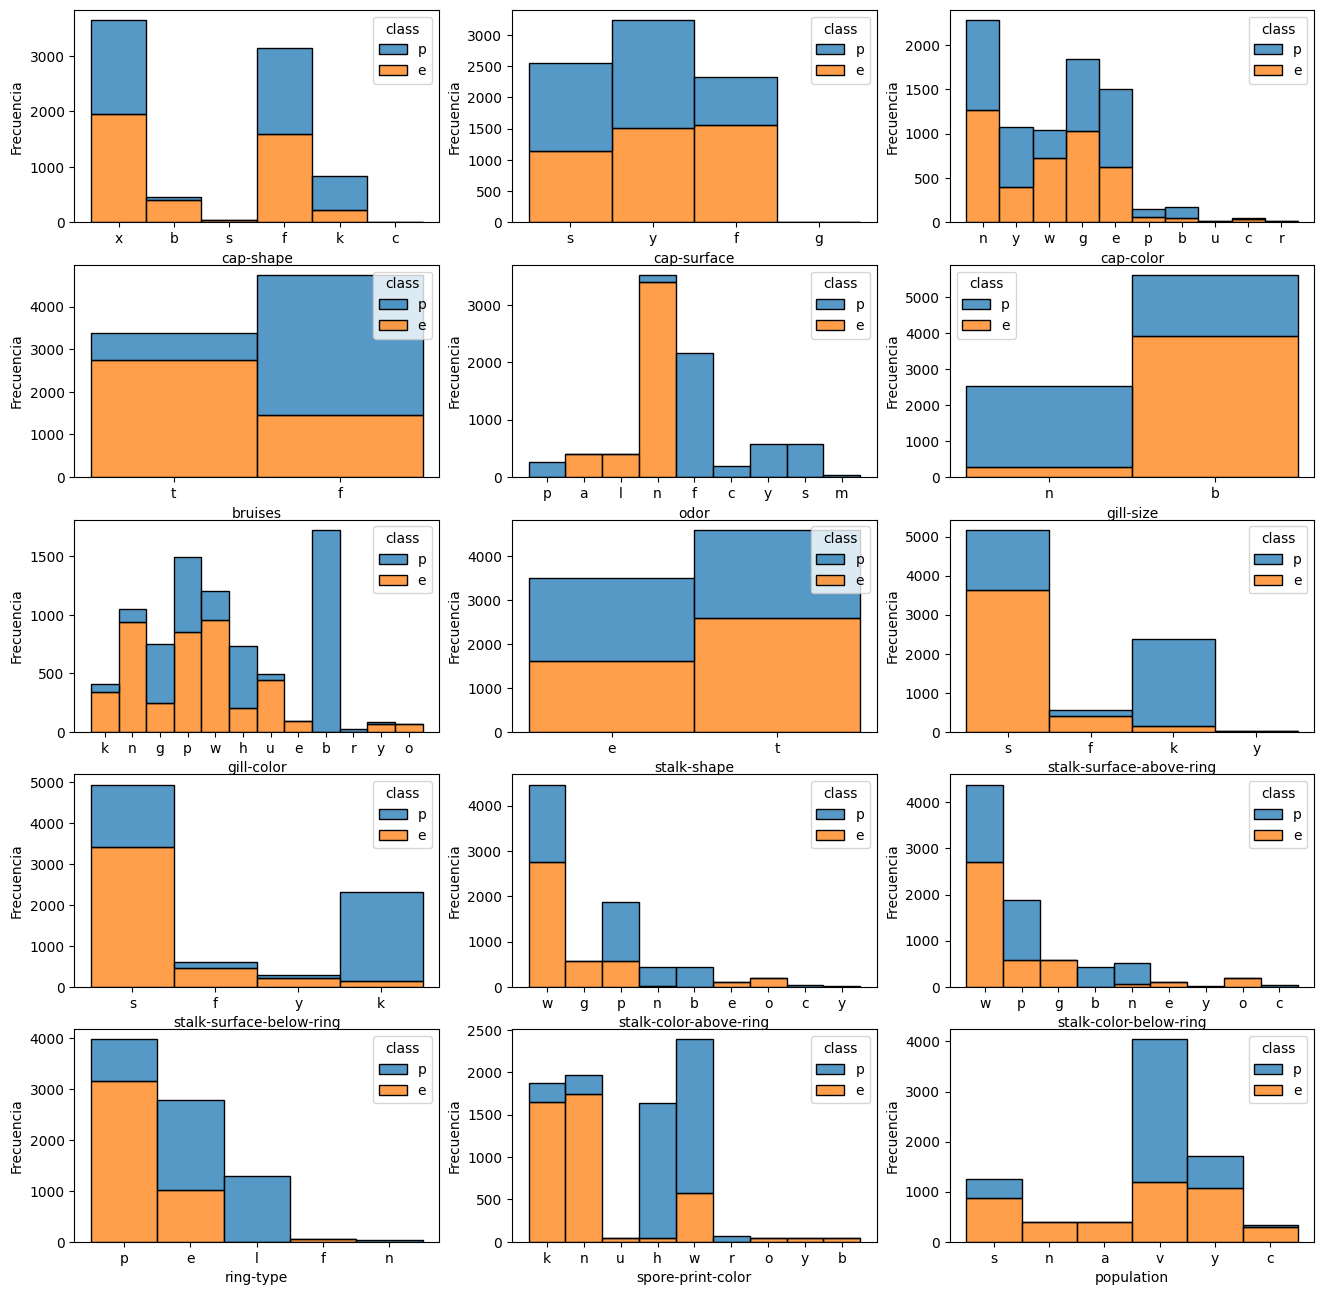

In [63]:
fig, ax = plt.subplots(nrows=5, ncols=3, figsize=(16, 16), sharex=False)

for i in (0,1,2,3,4):
  for j in (1,2,3):
    c=i*3+j
    sns.histplot(data=dfAgaricusLepiota[[NombresAtributos[c]]], x=dfAgaricusLepiota[NombresAtributos[c]], label=NombresAtributos[c],  ax=ax[i,j-1], hue=dfAgaricusLepiota['class'], multiple='stack')
    ax[i,j-1].set_xlabel(NombresAtributos[c])
    ax[i,j-1].set_ylabel('Frecuencia')

**Elección de atributos, según como dividen la variable objetivo**

Viendo los gráficos podríamos elegir como buenos separadores de las clases objetivos: bruises, gill-size, odor, spore-print-color, ring-type.
Crearemos **X** con esos 4 atributos de todas las intancias e **y** con la variable objetivo.

*PREGUNTA A LA CLASE*: Por qué no creamos una única estructura con las 5 columnas?

In [64]:
X = dfAgaricusLepiota[['bruises','gill-size','spore-print-color','ring-type']].values
XNombresAtributos=['bruises','gill-size','spore-print-color','ring-type']
yNombresClases=['e','p']
y = dfAgaricusLepiota['class'].values
print(X)
print(y)

[['t' 'n' 'k' 'p']
 ['t' 'b' 'n' 'p']
 ['t' 'b' 'n' 'p']
 ...
 ['f' 'b' 'b' 'p']
 ['f' 'n' 'w' 'e']
 ['f' 'b' 'o' 'p']]
['p' 'e' 'e' ... 'e' 'p' 'e']


**Tabla de contingencia de los 4 atributos seleccionados a partir de los gráficos**


In [65]:
for v in XNombresAtributos:
   tabla_contingencia= pd.crosstab(index=dfAgaricusLepiota['class'],columns=dfAgaricusLepiota[v])
   print(tabla_contingencia)


bruises     f     t
class              
e        1456  2752
p        3292   624
gill-size     b     n
class                
e          3920   288
p          1692  2224
spore-print-color   b     h     k     n   o   r   u     w   y
class                                                        
e                  48    48  1648  1744  48   0  48   576  48
p                   0  1584   224   224   0  72   0  1812   0
ring-type     e   f     l   n     p
class                              
e          1008  48     0   0  3152
p          1768   0  1296  36   816


**Prueba del chi-cuadrado de esas columnas**

In [66]:
for v in XNombresAtributos:
   print(v)
   print(stats.chi2_contingency(pd.crosstab(index=dfAgaricusLepiota['class'],columns=dfAgaricusLepiota[v])))



bruises
Chi2ContingencyResult(statistic=np.float64(2041.4156474619554), pvalue=np.float64(0.0), dof=1, expected_freq=array([[2459.32840965, 1748.67159035],
       [2288.67159035, 1627.32840965]]))
gill-size
Chi2ContingencyResult(statistic=np.float64(2366.8342569059605), pvalue=np.float64(0.0), dof=1, expected_freq=array([[2906.85573609, 1301.14426391],
       [2705.14426391, 1210.85573609]]))
spore-print-color
Chi2ContingencyResult(statistic=np.float64(4602.0331700846045), pvalue=np.float64(0.0), dof=8, expected_freq=array([[  24.86262925,  845.32939439,  969.64254062, 1019.36779911,
          24.86262925,   37.29394387,   24.86262925, 1236.91580502,
          24.86262925],
       [  23.13737075,  786.67060561,  902.35745938,  948.63220089,
          23.13737075,   34.70605613,   23.13737075, 1151.08419498,
          23.13737075]]))
ring-type
Chi2ContingencyResult(statistic=np.float64(2956.619278057532), pvalue=np.float64(0.0), dof=4, expected_freq=array([[1437.88872477,   24.86262925,

En los 4 casos el estadístico Chi2 da alto por lo tanto rechazamos la hipótesis nula, es decir las variables están asociadas (son dependientes). Por lo tanto es una elección correcta.

**Preparación de los datos para un modelo de arbol de decisión**

Los árboles en Python trabajan con variables categóricas pero numéricas por lo tanto será necesario codificarlas.
Para ello utilizaremos LabelEncoder.
Tanto para los atributos de entrada como también para la variable objetivo.

In [67]:
encoder = OneHotEncoder()
X_dummies= encoder.fit_transform(X).toarray()


print(X_dummies)


[[0. 1. 0. ... 0. 0. 1.]
 [0. 1. 1. ... 0. 0. 1.]
 [0. 1. 1. ... 0. 0. 1.]
 ...
 [1. 0. 1. ... 0. 0. 1.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 1. ... 0. 0. 1.]]


In [68]:
print(encoder.categories_)

[array(['f', 't'], dtype=object), array(['b', 'n'], dtype=object), array(['b', 'h', 'k', 'n', 'o', 'r', 'u', 'w', 'y'], dtype=object), array(['e', 'f', 'l', 'n', 'p'], dtype=object)]


In [69]:
encoded_feature_names = []
for i, cat in enumerate(encoder.categories_):
    for feature_val in cat:
        encoded_feature_names.append(f"{XNombresAtributos[i]}_No es_{feature_val}")

In [70]:
print(encoded_feature_names)

['bruises_No es_f', 'bruises_No es_t', 'gill-size_No es_b', 'gill-size_No es_n', 'spore-print-color_No es_b', 'spore-print-color_No es_h', 'spore-print-color_No es_k', 'spore-print-color_No es_n', 'spore-print-color_No es_o', 'spore-print-color_No es_r', 'spore-print-color_No es_u', 'spore-print-color_No es_w', 'spore-print-color_No es_y', 'ring-type_No es_e', 'ring-type_No es_f', 'ring-type_No es_l', 'ring-type_No es_n', 'ring-type_No es_p']


In [71]:
le= LabelEncoder()
y_encoded= le.fit_transform(y)
print(y_encoded)


[1 0 0 ... 0 1 0]


# Particionamiento
Como el tamaño del conjunto de datos es 8124, es un tamaño aceptable para una división 70% para entrenamiento y 30% para testeo



In [72]:
X_train, X_test, y_train, y_test = train_test_split(X_dummies, y_encoded, test_size = 0.3, random_state = 0)

# Selección, configuración y entrenamiento del modelo
Seleccionarremos un Arbol de Decisión de la librería sklearn, como mètrica para el armado del árbol setearemos "entropìa"

**Entropía**: es el grado de (im)pureza de un conjunto de instancias. Será 0 si todas las instancias pertenecen a la misma clase y será 1 si la cantidad de instancias de cada clase es idéntica.

NOTA: recordar que por ser un algoritmo supervisado debemos entrenar al modelo con las etiquetas correspondientes a las instancias utilizadas para el entrenamiento

In [73]:
arbol1 = DecisionTreeClassifier(criterion='entropy')
arbol1.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

1. Attribute Information: (class: edible=e, poisonous=p)


     bruises:
                                  bruises=t,no=f
     gill-size:
                                  broad=b,narrow=n
     spore-print-color:        
                                  black=k,brown=n,buff=b,chocolate=h,green=r,orange=o,purple=u,white=w,yellow=y
    
    ring-type:                
                                  cobwebby=c,evanescent=e,flaring=f,large=l,none=n,pendant=p,sheathing=s,zone=z
  
   

In [74]:
print(encoded_feature_names)

['bruises_No es_f', 'bruises_No es_t', 'gill-size_No es_b', 'gill-size_No es_n', 'spore-print-color_No es_b', 'spore-print-color_No es_h', 'spore-print-color_No es_k', 'spore-print-color_No es_n', 'spore-print-color_No es_o', 'spore-print-color_No es_r', 'spore-print-color_No es_u', 'spore-print-color_No es_w', 'spore-print-color_No es_y', 'ring-type_No es_e', 'ring-type_No es_f', 'ring-type_No es_l', 'ring-type_No es_n', 'ring-type_No es_p']


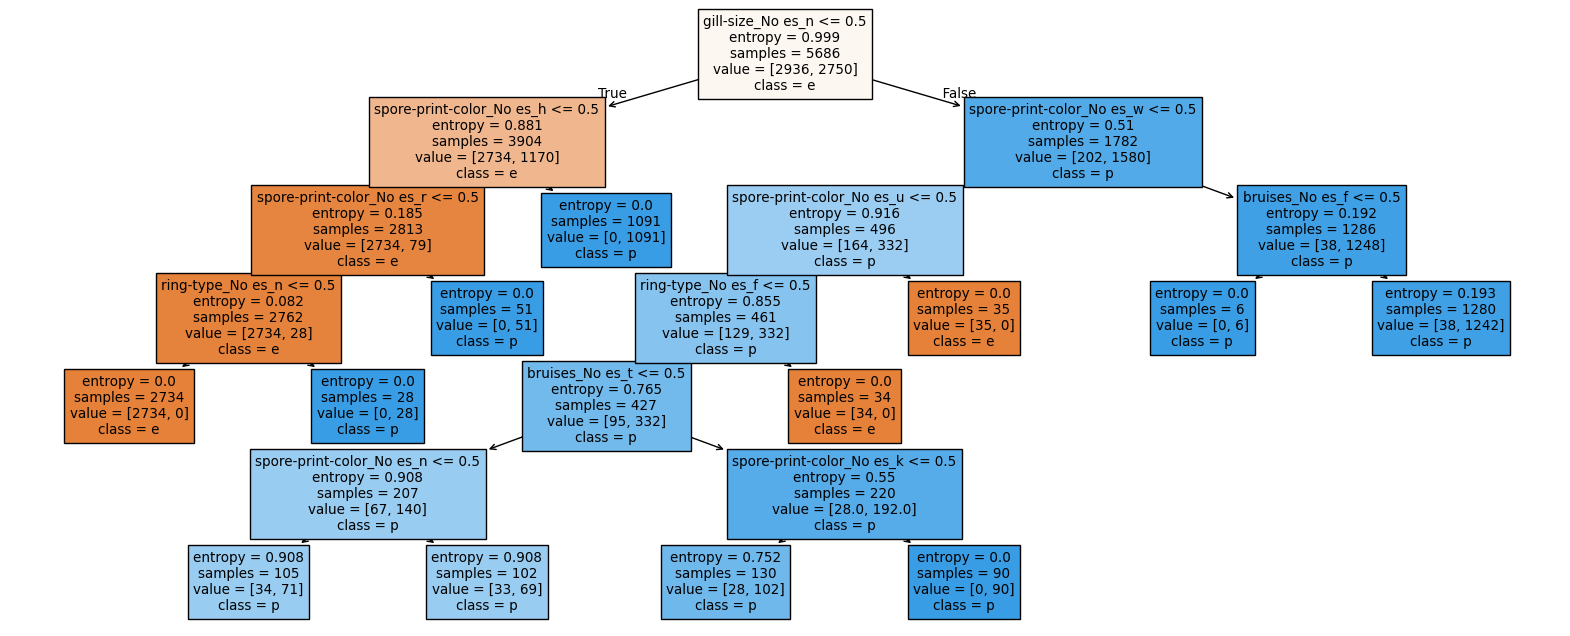

In [75]:
# While plotting the tree:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(20, 8), dpi=100)

tree.plot_tree(arbol1,
               feature_names=encoded_feature_names,  # Use encoded feature names
               class_names=le.classes_,
               filled=True)
fig.savefig('arbol1.png')

# Evaluación
Una vez entrenado el modelo, debemos realizar el test y evaluar los resultados. Por tratarse de una clasificación utilizaremos la matriz de confusión. A continuación recordamos las fórmulas con 2 clases (positivo y negativo)

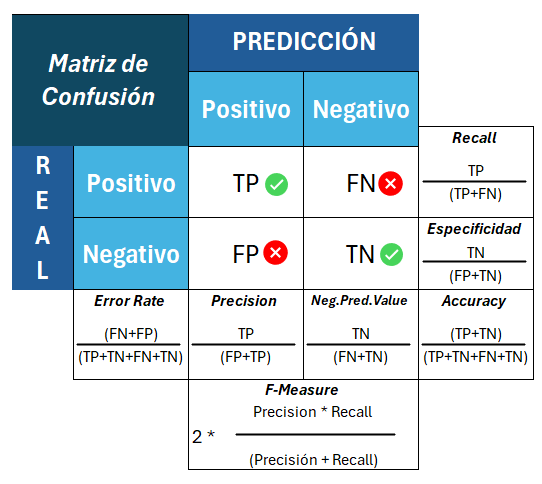

In [76]:
y_pred=arbol1.predict(X_test)

              precision    recall  f1-score   support

           e       1.00      0.95      0.98      1272
           p       0.95      1.00      0.98      1166

    accuracy                           0.98      2438
   macro avg       0.98      0.98      0.98      2438
weighted avg       0.98      0.98      0.98      2438



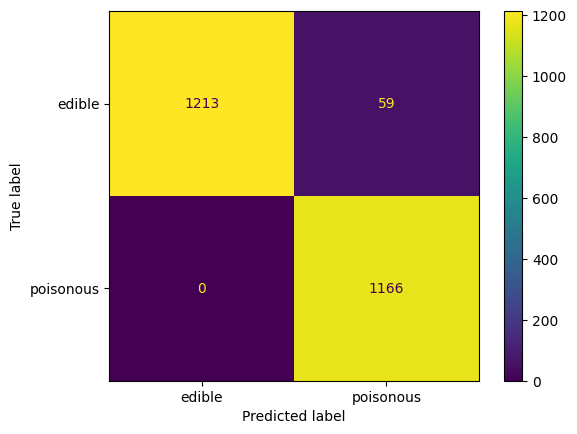

In [78]:
# Invertimos el encoder para poder visualizar los valores originnales de la clase objetivo

y_test_original = le.inverse_transform(y_test)
y_pred_original = le.inverse_transform(y_pred)

mc_arbol1 = confusion_matrix(y_test_original, y_pred_original)

mc_visual = metrics.ConfusionMatrixDisplay(confusion_matrix = mc_arbol1, display_labels = ['edible', 'poisonous'])
mc_visual.plot()

print(classification_report(y_test_original, y_pred_original))

# Conclusiones
El modelo tiene una buena calidad ya que tienen un accuracy de 0.98 pero además porque no tiene "falsos comestibles", es decir tuvo la máxima sensibilidad para detectar los hongos venenosos